In [1]:
!pip install -q kagglehub tqdm scikit-learn

import tensorflow as tf
print("TensorFlow:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("GPU:", "YES" if gpus else "NO")

TensorFlow: 2.19.0
GPU: YES


In [2]:
import kagglehub

path = kagglehub.dataset_download("zlatan599/garbage-dataset-classification")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-dataset-classification' dataset.
Path to dataset files: /kaggle/input/garbage-dataset-classification


In [3]:
from pathlib import Path

BASE = Path("/kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff", ".webp"}

def count_images(folder: Path, recursive: bool = False) -> int:
    if recursive:
        return sum(1 for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
    else:
        return sum(1 for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS)

if not BASE.exists():
    raise FileNotFoundError(f"file not found: {BASE}")
class_dirs = sorted([d for d in BASE.iterdir() if d.is_dir()])
total = 0

print(f"Base file: {BASE}\n")
for d in class_dirs:
    n = count_images(d, recursive=False)
    total += n
    print(f"{d.name:<12}: {n:5d}")

print("-" * 24)
print(f"{'sum':<12}: {total:5d}")

Base file: /kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images

cardboard   :  2214
glass       :  2500
metal       :  2084
paper       :  2315
plastic     :  2288
trash       :  2500
------------------------
sum         : 13901


In [4]:
import os
import shutil
import random

random.seed(42)
SOURCE_DIR = str(BASE)

DEST_DIR = "/kaggle/working/garbage_split"
SELECTED_CLASSES = ["cardboard", "glass", "metal", "paper", "plastic"]

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)
print("Using classes:", SELECTED_CLASSES)

for cls in SELECTED_CLASSES:
    cls_path = os.path.join(SOURCE_DIR, cls)

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))
    ]
    random.shuffle(images)
    n = len(images)
    train_end = int(n * TRAIN_RATIO)
    val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

    splits = {
        "train": images[:train_end],
        "val":   images[train_end:val_end],
        "test":  images[val_end:]
    }
    for split, files in splits.items():
        split_dir = os.path.join(DEST_DIR, split, cls)
        os.makedirs(split_dir, exist_ok=True)

        for file in files:
            shutil.copy(
                os.path.join(cls_path, file),
                os.path.join(split_dir, file)
            )

    print(
        f"{cls:<10} : "
        f"Train: {len(splits['train'])}, "
        f"Val: {len(splits['val'])}, "
        f"Test: {len(splits['test'])}"
    )


Using classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic']
cardboard  : Train: 1549, Val: 332, Test: 333
glass      : Train: 1750, Val: 375, Test: 375
metal      : Train: 1458, Val: 313, Test: 313
paper      : Train: 1620, Val: 347, Test: 348
plastic    : Train: 1601, Val: 343, Test: 344


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

TRAIN_DIR = f"{DEST_DIR}/train"
VAL_DIR   = f"{DEST_DIR}/val"
TEST_DIR  = f"{DEST_DIR}/test"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True
)

In [6]:
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_data = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
CLASS_NAMES = list(train_data.class_indices.keys())
print("Classes:", CLASS_NAMES)


Found 7978 images belonging to 5 classes.
Found 1710 images belonging to 5 classes.
Found 1713 images belonging to 5 classes.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic']


In [7]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV3Large(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)
model.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 3,279,749 (12.51 MB)

 Trainable params: 281,477 (1.07 MB)

 Non-trainable params: 2,998,272 (11.44 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks_stage1 = [
    ModelCheckpoint("mobilenetv3_best.keras", monitor="val_accuracy", save_best_only=True,verbose=1),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1 ),
    ReduceLROnPlateau(monitor="val_loss",factor=0.3,patience=3,min_lr=1e-6, verbose=1)
]
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks_stage1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.4078 - loss: 1.5353
Epoch 1: val_accuracy improved from -inf to 0.80643, saving model to mobilenetv3_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 167s 556ms/step - accuracy: 0.4084 - loss: 1.5341 - val_accuracy: 0.8064 - val_loss: 0.7054 - learning_rate: 1.0000e-04
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.7285 - loss: 0.8359
Epoch 2: val_accuracy improved from 0.80643 to 0.85556, saving model to mobilenetv3_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 97s 389ms/step - accuracy: 0.7286 - loss: 0.8357 - val_accuracy: 0.8556 - val_loss: 0.5951 - learning_rate: 1.0000e-04
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.7845 - loss: 0.7290
Epoch 3: val_accuracy improved from 0.85556 to 0.87427, saving model to mobilenetv3_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 97s 387ms/step - accuracy: 0.7845 - loss: 0.7289 - val_accuracy: 0.8743 - val_loss: 0.5563 - learning_rate: 1.0000e-04
Epoch 4/3

In [9]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

callbacks_stage2 = [
    ModelCheckpoint("mobilenetv3_best.keras", monitor="val_accuracy", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True, verbose=1 ),
    ReduceLROnPlateau( monitor="val_loss",factor=0.3,patience=3,min_lr=1e-6, verbose=1)
]
history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=callbacks_stage2,
    verbose=1
)


Epoch 1/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9003 - loss: 0.4991
Epoch 1: val_accuracy improved from -inf to 0.93860, saving model to mobilenetv3_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 145s 475ms/step - accuracy: 0.9003 - loss: 0.4990 - val_accuracy: 0.9386 - val_loss: 0.4120 - learning_rate: 1.0000e-05
Epoch 2/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9046 - loss: 0.4751
Epoch 2: val_accuracy did not improve from 0.93860
250/250 ━━━━━━━━━━━━━━━━━━━━ 96s 385ms/step - accuracy: 0.9046 - loss: 0.4750 - val_accuracy: 0.9368 - val_loss: 0.4143 - learning_rate: 1.0000e-05
Epoch 3/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9210 - loss: 0.4523
Epoch 3: val_accuracy did not improve from 0.93860
250/250 ━━━━━━━━━━━━━━━━━━━━ 97s 386ms/step - accuracy: 0.9210 - loss: 0.4522 - val_accuracy: 0.9374 - val_loss: 0.4119 - learning_rate: 1.0000e-05
Epoch 4/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.9277 - loss: 0.4401
Epoch 4: 

In [10]:
model.compile(
    optimizer=Adam(3e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks_stage2,
    verbose=1
)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9788 - loss: 0.3248
Epoch 1: val_accuracy did not improve from 0.95789
250/250 ━━━━━━━━━━━━━━━━━━━━ 140s 469ms/step - accuracy: 0.9788 - loss: 0.3247 - val_accuracy: 0.9561 - val_loss: 0.3558 - learning_rate: 3.0000e-06
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9825 - loss: 0.3181
Epoch 2: val_accuracy did not improve from 0.95789
250/250 ━━━━━━━━━━━━━━━━━━━━ 97s 387ms/step - accuracy: 0.9825 - loss: 0.3181 - val_accuracy: 0.9567 - val_loss: 0.3553 - learning_rate: 3.0000e-06
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9762 - loss: 0.3222
Epoch 3: val_accuracy did not improve from 0.95789
250/250 ━━━━━━━━━━━━━━━━━━━━ 97s 387ms/step - accuracy: 0.9762 - loss: 0.3222 - val_accuracy: 0.9561 - val_loss: 0.3546 - learning_rate: 3.0000e-06
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9820 - loss: 0.3185
Epoch 4: val_accuracy did not improve from 0.95789

In [11]:
from tensorflow.keras.models import load_model

best_model = load_model("mobilenetv3_best.keras")
test_loss, test_acc = best_model.evaluate(test_data)
print("TEST acc:", test_acc)
print("TEST loss:", test_loss)


54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 366ms/step - accuracy: 0.9643 - loss: 0.3416
TEST acc: 0.9579684734344482
TEST loss: 0.3516571819782257


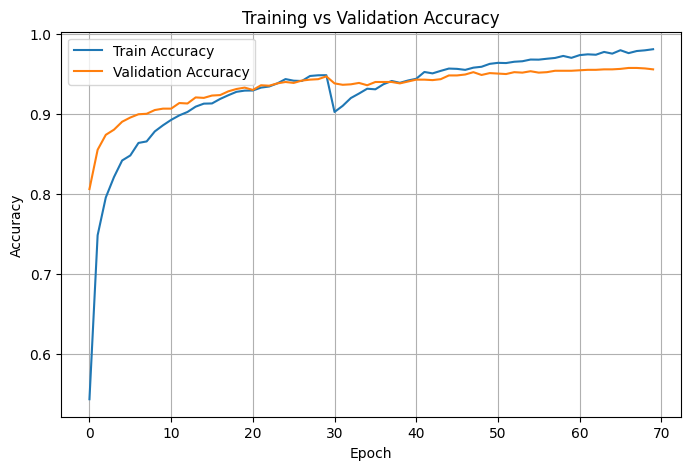

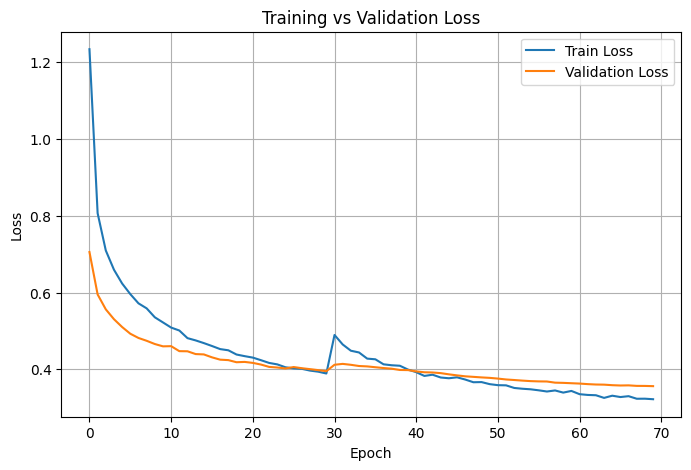

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history1.history['accuracy'] + history2.history['accuracy'], label='Train Accuracy')
plt.plot(history1.history['val_accuracy'] + history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history1.history['loss'] + history2.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'] + history2.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


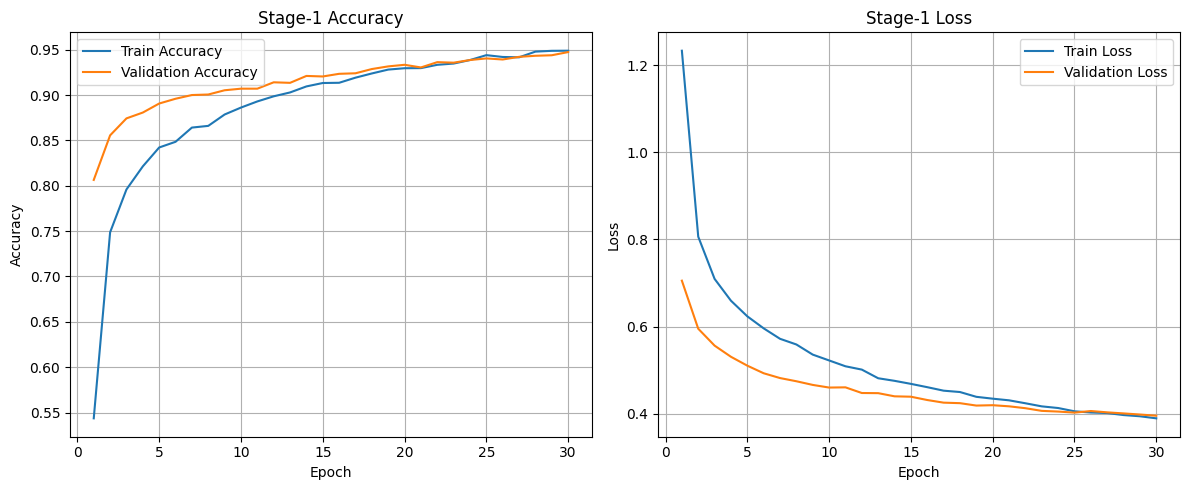

In [13]:
import matplotlib.pyplot as plt

epochs_stage1 = range(1, len(history1.history["accuracy"]) + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_stage1, history1.history["accuracy"], label="Train Accuracy")
plt.plot(epochs_stage1, history1.history["val_accuracy"], label="Validation Accuracy")
plt.title("Stage-1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs_stage1, history1.history["loss"], label="Train Loss")
plt.plot(epochs_stage1, history1.history["val_loss"], label="Validation Loss")
plt.title("Stage-1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


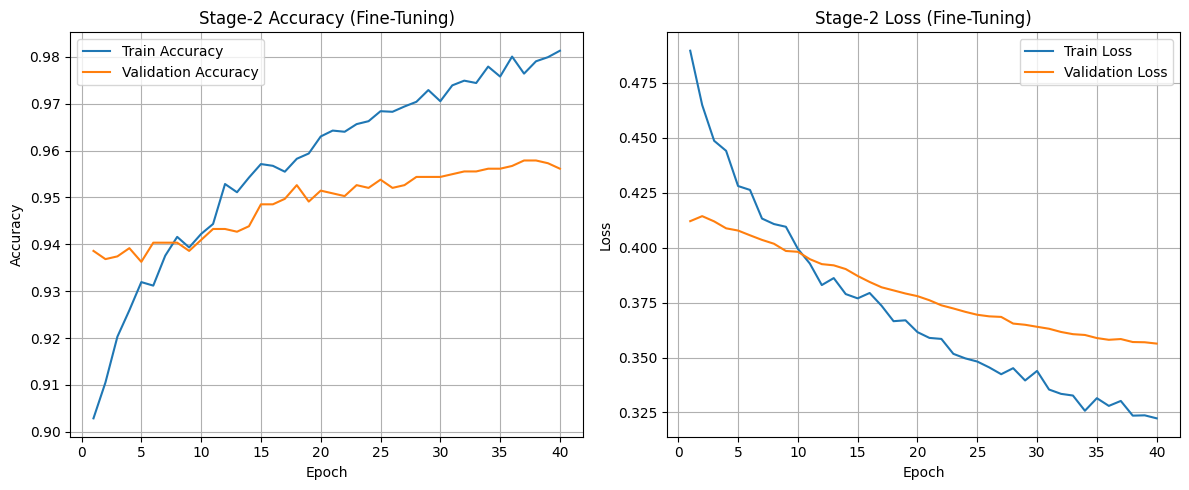

In [14]:
epochs_stage2 = range(1, len(history2.history["accuracy"]) + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_stage2, history2.history["accuracy"], label="Train Accuracy")
plt.plot(epochs_stage2, history2.history["val_accuracy"], label="Validation Accuracy")
plt.title("Stage-2 Accuracy (Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs_stage2, history2.history["loss"], label="Train Loss")
plt.plot(epochs_stage2, history2.history["val_loss"], label="Validation Loss")
plt.title("Stage-2 Loss (Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_prob = best_model.predict(test_data, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_data.classes
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Confusion Matrix:
 [[319   1   2   7   4]
 [  1 357   9   0   8]
 [  2   0 310   0   1]
 [ 11   0   2 335   0]
 [  4  10   7   3 320]]

Classification Report:

              precision    recall  f1-score   support

   cardboard       0.95      0.96      0.95       333
       glass       0.97      0.95      0.96       375
       metal       0.94      0.99      0.96       313
       paper       0.97      0.96      0.97       348
     plastic       0.96      0.93      0.95       344

    accuracy                           0.96      1713
   macro avg       0.96      0.96      0.96      1713
weighted avg       0.96      0.96      0.96      1713



In [16]:
model.save("mobilenetv3_final.keras")
